In [79]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv("data/processed_data.csv", parse_dates=["date"]).copy()

features = [
'diff_elo',
'diff_avg_goals_for', 
'diff_avg_goals_against',
'diff_avg_points', 
'diff_ranking',
'diff_fifa_points',
'ranking_local',
'ranking_away',
'change_local',
'change_away'
]

df_training = df[df["date"] < "2026-05-01"]
df_training = df_training.dropna(subset=features)

df_train = df_training[(df_training["date"] < "2023-06-01") ].copy()
X_train = df_train[features]
y_train = df_train["result"]
df_test = df_training[(df_training["date"] >= "2023-06-01") ].copy()
X_test = df_test[features]
y_test = df_test["result"]
y_test

modelo_gb = HistGradientBoostingClassifier(
    max_iter=100,  
    learning_rate=0.03,  # pasos cortos
    max_depth=3,  # limitamos la profundidad
    min_samples_leaf=70,  # Exigimos que al menos 30 partidos cumplan una regla para darla por válida
    random_state=45,
)

modelo_gb.fit(X_train, y_train)

predicciones = modelo_gb.predict(X_test)

# =================================================================
# PASO 4: Evaluar los resultados en consola
# =================================================================
# Calculamos el porcentaje total de aciertos
precision = accuracy_score(y_test, predicciones)

print(f"La precisión es de gradient tree boosting es: {precision * 100:.2f}%")
print("\nPor cada resultado (1=Local, 0=Empate, 2=Visitante):")
print(classification_report(y_test, predicciones))

df

La precisión es de gradient tree boosting es: 60.59%

Por cada resultado (1=Local, 0=Empate, 2=Visitante):
              precision    recall  f1-score   support

           0       0.55      0.01      0.02       613
           1       0.61      0.89      0.72      1152
           2       0.60      0.65      0.62       747

    accuracy                           0.61      2512
   macro avg       0.59      0.52      0.46      2512
weighted avg       0.59      0.61      0.52      2512



,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,ranking_local,fifa_points_away,ranking_away,elo_local,change_local,elo_away,change_away,diff_elo,diff_ranking,diff_fifa_points
0,1993-01-01,Ghana,Mali,1.0,1.0,Friendly,Libreville,Gabon,True,0,...,39.0,22.00,69.0,1622.0,-12.0,1404.0,11.0,218.0,-30.0,12.00
1,1993-01-02,Gabon,BurkinaFaso,1.0,1.0,Friendly,Libreville,Gabon,False,0,...,55.0,11.00,97.0,1443.0,4.0,1324.0,-8.0,119.0,-42.0,16.00
2,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,KuwaitCity,Kuwait,False,1,...,71.0,0.00,161.0,1491.0,-33.0,1252.0,-4.0,239.0,-90.0,21.00
3,1993-01-03,BurkinaFaso,Mali,1.0,0.0,Friendly,Libreville,Gabon,True,1,...,97.0,22.00,69.0,1324.0,-8.0,1404.0,11.0,-80.0,28.0,-11.00
4,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,2,...,55.0,34.00,39.0,1443.0,4.0,1622.0,-12.0,-179.0,16.0,-7.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30578,2026-06-27,Panama,England,NaN,NaN,FIFAWorldCup,EastRutherford,UnitedStates,True,0,...,43.0,1787.88,5.0,1729.0,4.0,2019.0,35.0,-290.0,38.0,-305.78
30579,2026-06-27,Jordan,Argentina,NaN,NaN,FIFAWorldCup,Arlington,UnitedStates,True,0,...,68.0,1860.14,1.0,1634.0,3.0,2109.0,-27.0,-475.0,67.0,-486.01
30580,2026-06-27,DRCongo,Uzbekistan,NaN,NaN,FIFAWorldCup,Atlanta,UnitedStates,True,0,...,NaN,1397.41,62.0,NaN,NaN,1708.0,13.0,NaN,NaN,NaN
30581,2026-06-27,Colombia,Portugal,NaN,NaN,FIFAWorldCup,MiamiGardens,UnitedStates,True,0,...,12.0,1747.04,6.0,1981.0,24.0,2041.0,8.0,-60.0,6.0,-77.60


In [80]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150, 
        max_depth=5, 
        min_samples_leaf=50, 
        random_state=45
    ),
    "Gradient Boosting (Sklearn)": GradientBoostingClassifier(
        n_estimators=100, 
        learning_rate=0.03, 
        max_depth=3, 
        min_samples_leaf=50, 
        random_state=45
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=45
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100, 
        learning_rate=0.03, 
        max_depth=3, 
        min_child_samples=50, 
        random_state=45,
        verbosity=-1 # Silencia los logs repetitivos
    ),
    "HistGradientBoostingClassifier": HistGradientBoostingClassifier(
    max_iter=100,  
    learning_rate=0.03,  # pasos cortos
    max_depth=3,  # limitamos la profundidad
    min_samples_leaf=70,  # Exigimos que al menos 30 partidos cumplan una regla para darla por válida
    random_state=45,
)

}


results = []

# Bucle para entrenar, predecir y evaluar cada modelo automáticamente
for name, model in models.items():
    # Entrenar
    model.fit(X_train, y_train)
    # Predecir
    preds = model.predict(X_test)
    # Evaluar precisión general
    acc = accuracy_score(y_test, preds)
    
    # Guardar métricas en la lista
    results.append({
        "Model": name,
        "Accuracy Total": f"{acc * 100:.2f}%",
        "Numerical Metric": acc
    })
    
    # Imprimir el reporte detallado en consola para revisar los empates (0)
    print(f"=== REPORTE DETALLADO: {name} ===")
    print(classification_report(y_test, preds, zero_division=0))
    print("-" * 50)

# Crear un DataFrame para ver el ranking de modelos de forma limpia
df_ranking_modelos = pd.DataFrame(results).sort_values(by="Numerical Metric", ascending=False)
df_ranking_modelos = df_ranking_modelos.drop(columns=["Numerical Metric"])

print("\n BEST MODELS RANKING:")
print(df_ranking_modelos.to_string(index=False))


=== REPORTE DETALLADO: Random Forest ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       613
           1       0.60      0.90      0.72      1152
           2       0.60      0.64      0.62       747

    accuracy                           0.60      2512
   macro avg       0.40      0.51      0.45      2512
weighted avg       0.45      0.60      0.51      2512

--------------------------------------------------
=== REPORTE DETALLADO: Gradient Boosting (Sklearn) ===
              precision    recall  f1-score   support

           0       0.56      0.01      0.02       613
           1       0.60      0.90      0.72      1152
           2       0.60      0.64      0.62       747

    accuracy                           0.60      2512
   macro avg       0.59      0.51      0.45      2512
weighted avg       0.59      0.60      0.52      2512

--------------------------------------------------


c:\Users\TrendingPc\Documents\project\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== REPORTE DETALLADO: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       613
           1       0.61      0.90      0.73      1152
           2       0.61      0.66      0.63       747

    accuracy                           0.61      2512
   macro avg       0.41      0.52      0.45      2512
weighted avg       0.46      0.61      0.52      2512

--------------------------------------------------
=== REPORTE DETALLADO: LightGBM ===
              precision    recall  f1-score   support

           0       1.00      0.00      0.01       613
           1       0.61      0.89      0.72      1152
           2       0.59      0.64      0.62       747

    accuracy                           0.60      2512
   macro avg       0.73      0.51      0.45      2512
weighted avg       0.70      0.60      0.52      2512

--------------------------------------------------
=== REPORTE DETALLADO: HistGradientBoostingClassifier

In [81]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


lightgbm = models["LightGBM"]
lightgbm.fit(X_train, y_train)


probs = lightgbm.predict_proba(X_test)


optimized_predictions = []
treshold = 0.12

for p in probs:
    prob_empate, prob_local, prob_visitante = p[0], p[1], p[2]
    

    diferencia_local_visitante = abs(prob_local - prob_visitante)
    
    if diferencia_local_visitante < treshold:  
        optimized_predictions.append(0) 
    else:
        
        if prob_local > prob_visitante:
            optimized_predictions.append(1)
        else:
            optimized_predictions.append(2)

optimized_predictions = np.array(optimized_predictions)


print(f"Light GBM : {accuracy_score(y_test, optimized_predictions) * 100:.2f}%")
print("\n Report with Optimized Threshold:")
print(classification_report(y_test, optimized_predictions))


Light GBM : 60.11%

 Report with Optimized Threshold:
              precision    recall  f1-score   support

           0       0.31      0.17      0.22       613
           1       0.64      0.86      0.73      1152
           2       0.66      0.56      0.60       747

    accuracy                           0.60      2512
   macro avg       0.54      0.53      0.52      2512
weighted avg       0.56      0.60      0.57      2512



C:\Users\TrendingPc\AppData\Local\Temp\ipykernel_20696\989423258.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


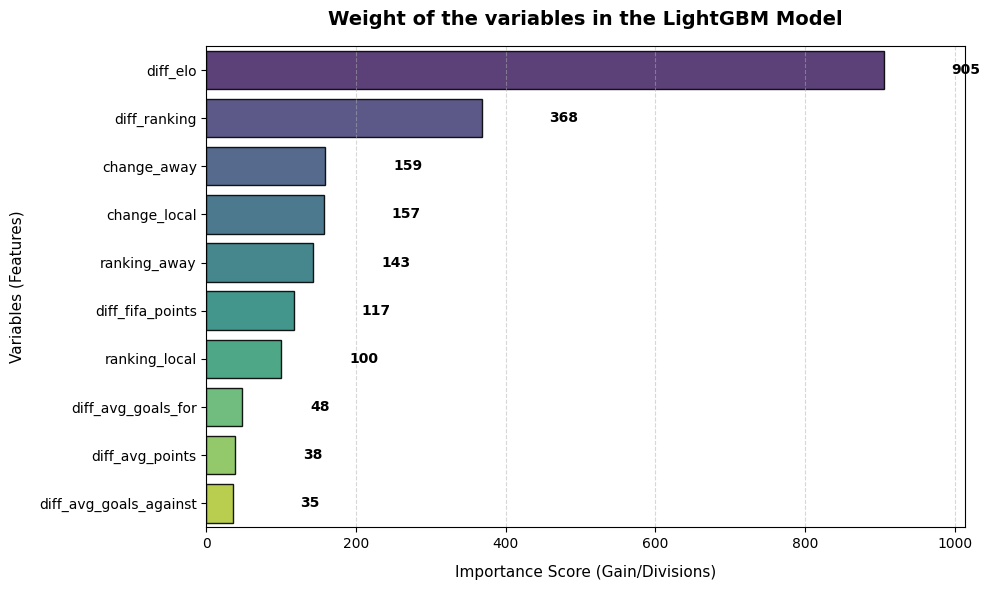

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que el modelo LightGBM esté entrenado
best_model = models["LightGBM"]
best_model.fit(X_train, y_train)

# 2. Extraer la importancia de las variables
importancias = best_model.feature_importances_

# 3. Crear un DataFrame para ordenar y manipular los datos fácilmente
df_importancia = pd.DataFrame({
    'Variable': features,
    'Weight': importancias
}).sort_values(by='Weight', ascending=False)

# --- DISEÑO DEL GRÁFICO EN MATPLOTLIB / SEABORN ---
plt.figure(figsize=(10, 6))

# Dibujar gráfico de barras horizontal
sns.barplot(
    x='Weight', 
    y='Variable', 
    data=df_importancia, 
    palette='viridis', # Degradado de color elegante
    edgecolor='black',
    alpha=0.9
)

# Añadir las etiquetas con el valor numérico exacto al final de cada barra
for index, value in enumerate(df_importancia['Weight']):
    plt.text(
        value + (max(importancias) * 0.1), # Pequeño margen a la derecha de la barra
        index, 
        f'{value}', 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

# Configuración de textos y etiquetas
plt.title('Weight of the variables in the LightGBM Model', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Gain/Divisions)', fontsize=11, labelpad=10)
plt.ylabel('Variables (Features)', fontsize=11, labelpad=10)

# Ajustes visuales de las líneas de cuadrícula
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, max(importancias) * 1.12) # Damos margen a la derecha para que no se corten los números

# Mostrar y ajustar el diseño
plt.tight_layout()
plt.show()


In [83]:
df.columns = df.columns.str.strip()
df_world_cup = df[df["date"] >= "2026-05-01"].copy()
df_world_cup.columns = df_world_cup.columns.str.strip()
group_map = {
    # Grupo A
    "Mexico": "A",
    "SouthAfrica": "A",
    "KoreaRepublic": "A",
    "CzechRepublic": "A", 
    # Grupo B
    "Canada": "B",
    "BosniaandHerzegovina": "B",
    "Qatar": "B",
    "Switzerland": "B",
    # Grupo C
    "Brazil": "C",
    "Morocco": "C",
    "Haiti": "C",
    "Scotland": "C",
    # Grupo D
    "UnitedStates": "D",
    "Paraguay": "D",
    "Australia": "D",
    "Turkey": "D",
    # Grupo E
    "Germany": "E",
    "Curaçao": "E",
    "IvoryCoast": "E",
    "Ecuador": "E",
    # Grupo F
    "Netherlands": "F",
    "Japan": "F",
    "Sweden": "F",
    "Tunisia": "F",
    # Grupo G
    "Belgium": "G",
    "Egypt": "G",
    "Iran": "G",
    "New Zealand": "G",
    # Grupo H
    "Spain": "H",
    "CapeVerde": "H",
    "Uruguay": "H",
    "SaudiArabia": "H",
    # Grupo I
    "France": "I",
    "Senegal": "I",
    "Iraq": "I",
    "Norway": "I",
    # Grupo J
    "Argentina": "J",
    "Algeria": "J",
    "Austria": "J",
    "Jordan": "J",
    # Grupo K
    "Portugal": "K",
    "Congo": "K",
    "Uzbekistan": "K",
    "Colombia": "K",
    # Grupo L
    "England": "L",
    "Ghana": "L",
    "Croatia": "L",
    "Panama": "L",
}
    

df_world_cup["group"] = df_world_cup["home_team"].map(group_map)

df_world_cup["group"] = df_world_cup["group"]

df_world_cup

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,fifa_points_away,ranking_away,elo_local,change_local,elo_away,change_away,diff_elo,diff_ranking,diff_fifa_points,group
30511,2026-06-11,SouthKorea,CzechRepublic,NaN,NaN,FIFAWorldCup,Zapopan,Mexico,True,0,...,1502.90,32.0,1774.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
30512,2026-06-11,Mexico,SouthAfrica,NaN,NaN,FIFAWorldCup,MexicoCity,Mexico,False,0,...,1416.66,59.0,1859.0,-3.0,1527.0,-3.0,332.0,-44.0,235.67,A
30513,2026-06-12,Canada,BosniaandHerzegovina,NaN,NaN,FIFAWorldCup,Toronto,Canada,False,0,...,1332.30,75.0,1797.0,11.0,1516.0,-9.0,281.0,-27.0,129.44,B
30514,2026-06-12,UnitedStates,Paraguay,NaN,NaN,FIFAWorldCup,Inglewood,UnitedStates,False,0,...,1427.11,58.0,1698.0,19.0,1844.0,20.0,-146.0,NaN,NaN,D
30515,2026-06-13,Australia,Turkey,NaN,NaN,FIFAWorldCup,Vancouver,Canada,True,0,...,1493.38,42.0,1791.0,12.0,1836.0,-11.0,-45.0,-19.0,77.91,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30578,2026-06-27,Panama,England,NaN,NaN,FIFAWorldCup,EastRutherford,UnitedStates,True,0,...,1787.88,5.0,1729.0,4.0,2019.0,35.0,-290.0,38.0,-305.78,L
30579,2026-06-27,Jordan,Argentina,NaN,NaN,FIFAWorldCup,Arlington,UnitedStates,True,0,...,1860.14,1.0,1634.0,3.0,2109.0,-27.0,-475.0,67.0,-486.01,J
30580,2026-06-27,DRCongo,Uzbekistan,NaN,NaN,FIFAWorldCup,Atlanta,UnitedStates,True,0,...,1397.41,62.0,NaN,NaN,1708.0,13.0,NaN,NaN,NaN,NaN
30581,2026-06-27,Colombia,Portugal,NaN,NaN,FIFAWorldCup,MiamiGardens,UnitedStates,True,0,...,1747.04,6.0,1981.0,24.0,2041.0,8.0,-60.0,6.0,-77.60,K


In [84]:
N_SIMULATIONS = 10000

probs = lightgbm.predict_proba(df_world_cup[features])

df_world_cup["p_draw"] = probs[:, 0]
df_world_cup["p_local"] = probs[:, 1]
df_world_cup["p_away"] = probs[:, 2]

classified_count = {}

def montecarlo_step(p_draw, p_local, p_away):
    rndm = np.random.rand()
    if rndm < p_draw:
        return 0
    elif rndm < (p_draw + p_local):
        return 1
    else:
        return 2
    
for sim in range(N_SIMULATIONS):
    # Puntos desde cero para cada selección participante
    all_teams = pd.concat(
        [df_world_cup["home_team"], df_world_cup["away_team"]]
    ).unique()
    points_simulation = {team: 0 for team in all_teams}

    for idx, match in df_world_cup.iterrows():
        loc = match["home_team"]
        vis = match["away_team"]

        res = montecarlo_step(match["p_draw"], match["p_local"], match["p_away"])

        if res == 1:
            points_simulation[loc] += 3
        elif res == 2:
            points_simulation[vis] += 3
        else:
            points_simulation[loc] += 1
            points_simulation[vis] += 1

    # Armamos la tabla de posiciones de esta iteración concreta
    df_positions = pd.DataFrame(list(points_simulation.items()), columns=["team", "points"])
    df_positions["grupo"] = (
        df_positions["team"].map(group_map)
    )

    # Ordenamos de forma estricta por grupo y puntos conseguidos
    df_positions = df_positions.sort_values(
        by=["grupo", "points"], ascending=[True, False]
    )

    # Extraemos el Top 2 de cada grupo (los clasificados directos)
    classified = df_positions.groupby("grupo").head(2)["team"].values

    for team in classified:
        classified_count[team] = classified_count.get(team, 0) + 1

# =====================================================================
# 5. MOSTRAR RESULTADOS ORDENADOS POR GRUPO
# =====================================================================
df_final = pd.DataFrame(
    [
        {
            "Team": eq,
            "Group": group_map.get(eq, "others"),
            "Probability_of_Classifying_%": (times_classified / N_SIMULATIONS) * 100,
        }
        for eq, times_classified in classified_count.items()
    ]
)

df_final = df_final.sort_values(
    by=["Group", "Probability_of_Classifying_%"], ascending=[True, False]
)

print("\nPROBABILITY OF CLASSIFYING TO THE NEXT ROUND:")
print(
    "================================================================================="
)
print(df_final.to_string(index=False))



PROBABILITY OF CLASSIFYING TO THE NEXT ROUND:
                Team Group  Probability_of_Classifying_%
              Mexico     A                         95.61
       CzechRepublic     A                         77.14
         SouthAfrica     A                         27.25
              Canada     B                         89.48
         Switzerland     B                         79.38
               Qatar     B                         21.77
BosniaandHerzegovina     B                          9.37
              Brazil     C                         88.13
            Scotland     C                         60.43
             Morocco     C                         41.43
               Haiti     C                         10.01
        UnitedStates     D                         62.69
           Australia     D                         52.53
              Turkey     D                         43.62
            Paraguay     D                         41.16
             Germany     E               